https://judge.nitro-ai.org/competitions/ceoai/ceoai-2026-practice-1/1/view
# The Stochastic Rift

**Central European Olympiad in Artificial Intelligence**

---

## 1. The Mission
*"Probability is not a constant. Here, it is a predator."*

Deep within the Cronus Hyper-Grid, **Sector 7** has destabilized. The topology of the network has fractured into a stochastic mess of quantum states. We need to extract a stranded kernel from the core, but active navigation is impossible.

You have been tasked with programming the **Navigator Oracle**. Since we cannot simulate the environment without collapsing the wave function, your only source of information is the **"Black Box" Flight Log** recovered from a previous, failed reconnaissance drone.

**Your Objective:** Using only this static, historical dataset, you must determine the **True Optimal Value ($V^*$)** of specific starting states.

## 2. The Environment
Sector 7 is modeled as a **Stochastic Markov Decision Process (MDP)**: $\mathcal{M} = \langle S, A, P, R, \gamma \rangle$.

*   **States ($S$):** A discrete set of nodes ($0 \dots N-1$).
*   **Actions ($A$):** 4 navigational impulses ($0 \dots 3$).
*   **Dynamics ($P$):** $P(s'|s, a)$ is unknown and highly stochastic.
*   **Reward ($R$):** The reward function is noisy.
*   **Discount ($\gamma$):** Exactly **0.99**.

Your task is to estimate the value of the optimal policy $\pi^*$ for a set of query states:
$$V^*(s) = \max_{\pi} \mathbb{E}_{\pi} \left[ \sum_{t=0}^{\infty} \gamma^t r_t \mid s_0 = s \right]$$

## 3. Dataset Description
You are provided with three files:

1.  **`sector_logs.csv`**: ~6,000 recorded transitions from a failed drone. The data is non-sequential (shuffled) and sparse.
    *   Columns: `current_state`, `action`, `reward`, `next_state`
2.  **`query_states.csv`**: The states for which Central Command requires value estimates.
    *   Columns: `id`, `state_id`
3.  **`env.py`**: A Python definition of the environment class. Contains a `step()` method for local simulation.

## 4. Evaluation & Scoring
We compute the **Mean Squared Error (MSE)** between your predicted values $\hat{V}$ and the true optimal values $V^*$.

$$ \text{MSE} = \frac{1}{K} \sum_{i=1}^{K} (\hat{V}(s_i) - V^*(s_i))^2 $$

**Thresholds:**
*   $MSE_{baseline} = 4000.0$
*   $MSE_{optimal} = 210.0$

**Scoring Formula:**
$$ \text{Points} = \text{round}\left(100 \times \frac{MSE_{baseline} - MSE_{yours}}{MSE_{baseline} - MSE_{optimal}}\right) $$

*   If $MSE_{yours} \ge 4000.0$, you receive **0 points**.
*   If $MSE_{yours} \le 210.0$, you receive **100 points**.

In [316]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import sys

# Ensure env.py can be imported if it's in the current directory
sys.path.append('.')

In [317]:
# Load the dataset files
# Assumes files are located in the current directory
try:
    logs_df = pd.read_csv('sector_logs.csv')
    query_df = pd.read_csv('query_states.csv')
    print("✅ Datasets loaded successfully.")
    print(f"Logs Shape: {logs_df.shape}")
    print(f"Query States Count: {len(query_df)}")
except FileNotFoundError:
    print("❌ Files not found. Please ensure 'sector_logs.csv' and 'query_states.csv' are uploaded.")

✅ Datasets loaded successfully.
Logs Shape: (6000, 4)
Query States Count: 1000


## 5. Exploratory Data Analysis (EDA)
The PDF shows a visualization of the "Fractured State Space". Let's attempt to reconstruct this graph from the `sector_logs.csv` to understand the topology.

We will visualize a sample of the transitions.

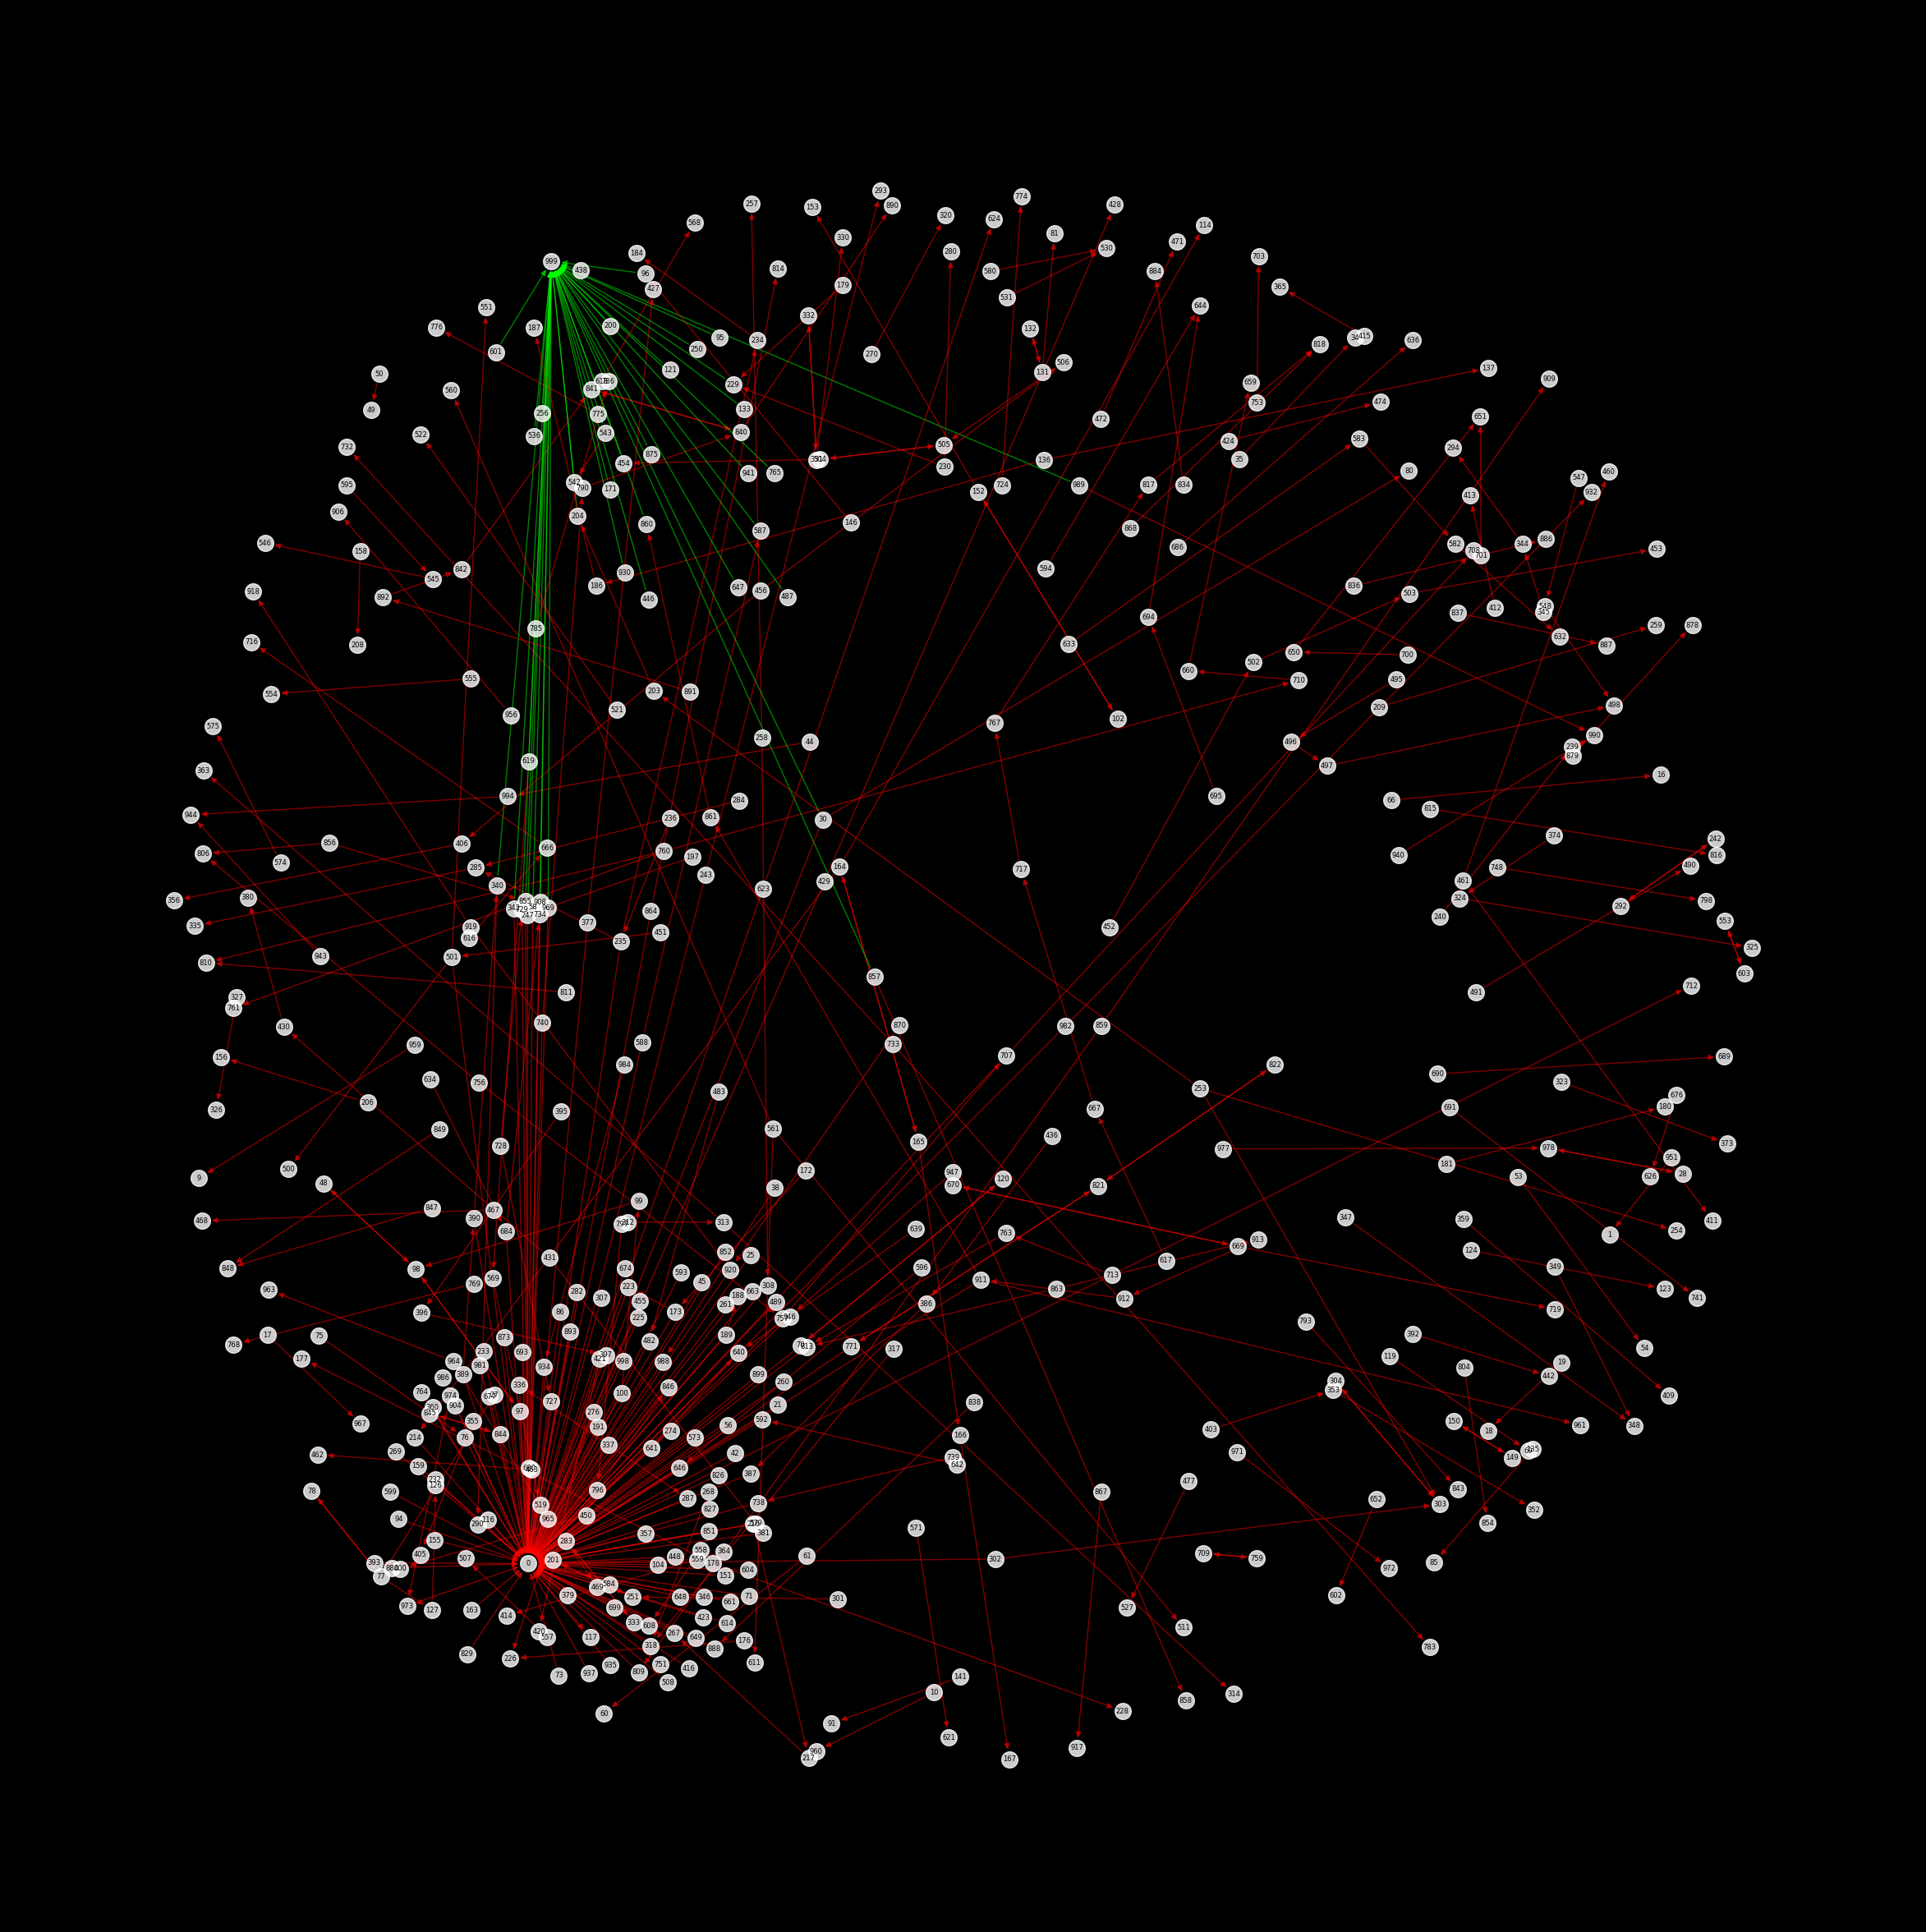

In [318]:
if 'logs_df' in locals():
    # Create a directed graph
    G = nx.DiGraph()

    # Sample 500 transitions to avoid overplotting
    sample_df = logs_df.sample(n=min(500, len(logs_df)), random_state=42)

    for _, row in sample_df.iterrows():
        u, v = int(row['current_state']), int(row['next_state'])
        r = row['reward']
        # Color edge green if positive reward, red if negative
        color = '#00ff00' if r > 0 else '#ff0000'
        G.add_edge(u, v, color=color)

    # Plot
    plt.figure(figsize=(30, 30))
    pos = nx.spring_layout(G, k=0.15, seed=42)
    colors = [G[u][v]['color'] for u,v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=200, node_color='white', alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color=colors, alpha=0.5, arrows=True)
    nx.draw_networkx_labels(G, pos, font_size=6)

    plt.title("Sector 7: Partial Topology Reconstruction")
    plt.axis('off')
    # Set dark background to match PDF style
    plt.gca().set_facecolor('black')
    plt.gcf().set_facecolor('black')
    plt.show()

# 🚀 Baseline:

The problem asks us to find $V^*(s)$, the value under the **Optimal Policy**.

Assume we don't know the optimal strategy and simply act randomly. We will use the provided `env.py` to simulate a random agent.

In [319]:
lookup = dict()

for idx, row in logs_df.groupby(['current_state', 'next_state', 'action']).max().iterrows():
    lookup[row.name] = row['reward']
len(lookup)

3279

In [320]:
logs_df = logs_df.sort_values(['current_state', 'action']).reset_index(drop=True)
logs_df

,current_state,action,reward,next_state
0,10,3,-1.07,960
1,11,0,300.03,999
2,11,2,-100.09,0
3,12,2,-1.01,62
4,12,3,-100.00,0
...,...,...,...,...
5995,998,0,300.08,999
5996,998,0,-100.10,0
5997,998,1,-0.98,997
5998,998,2,-0.94,48


In [321]:
prev = -1
st, oc = dict(), dict()
for idx, row in logs_df.iterrows():
    s = row['current_state']
    if prev != s:
        st[s] = idx
        oc[s] = 0
    else:
        oc[s] += 1
    prev = s

In [322]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from env import Sector7Env  # Imports the provided skeleton

np.random.seed(42)

# --- CONFIGURATION ---
GAMMA = 0.99
OUTPUT_FILE = 'submission.csv'

def solve_baseline():
    # 1. Initialize the provided environment
    env = Sector7Env()
    num_states = env.n_states
    num_actions = env.n_actions

    print(f"Environment Loaded. States: {num_states}, Actions: {num_actions}")

    # 2. Run Value Iteration using the Environment's Physics
    # Since we have the simulator code, we can just query the model directly.

    V = np.zeros(num_states)
    lr = 0.05

    # We iterate until the values converge based on the 'env.py' rules
    for i in tqdm(range(25)):
        delta = 0
        new_V = np.copy(V)

        s = np.random.randint(num_states)
        info = []

        relta = 0

        itr = 0

        for iter in range(100000):
            itr += 1
            # Skip terminal states (value stays 0 or fixed reward)
            # In the provided env, Goal is terminal.
            if s in env.terminals:
                break

            a = np.random.randint(num_actions)
            env.state = s
            next_s, reward, done, _ = env.step(a)

            # if (s, next_s, a) in lookup:
            #     reward = lookup[(s, next_s, a)]

            v_next = V[next_s]
            if done: v_next = 0 # Value of terminal state is 0

            q_val = reward + GAMMA * v_next
    
            best_val = q_val
            new_V[s] = best_val * lr + new_V[s] * (1-lr)
            delta = max(delta, abs(new_V[s] - V[s]))
            relta += delta
            s = next_s

        V = new_V
        if relta/itr < 1e-6:
            print(f"Simulation2 Converged at iteration {i}")
            break

    # 3. Generate Submission
    try:
        df_query = pd.read_csv('query_states.csv')
    except FileNotFoundError:
        print("query_states.csv not found.")
        return

    results = []
    for idx, row in df_query.iterrows():
        s_id = row['state_id']
        val = V[s_id] if s_id < num_states else 0.0
        results.append([1, row['id'], val])

    df_res = pd.DataFrame(results, columns=['subtaskID', 'datapointID', 'answer'])
    df_res.to_csv(OUTPUT_FILE, index=False)
    print(f"Saved simulation predictions to {OUTPUT_FILE}")

if __name__ == "__main__":
    solve_baseline()

Environment Loaded. States: 1000, Actions: 4


  0%|          | 0/25 [00:00<?, ?it/s]

Saved simulation predictions to submission.csv
